In [2]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
df_org=pd.read_csv('Telco_churn_dataset.csv')

In [4]:
df_org.sample(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
859,5275-PMFUT,Male,0,Yes,Yes,72,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),64.80,4719.75,No
5388,5515-IDEJJ,Male,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.90,19.9,Yes
6722,5481-NTDOH,Female,1,Yes,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),107.05,7142.5,No
5835,4641-FROLU,Female,0,Yes,Yes,30,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.30,602.9,No


In [5]:
X = df_org.drop('Churn', axis=1)
Y = df_org['Churn']

In [6]:
Y = Y.map({
    'Yes':1,
    'No':0
})
Y = Y.astype(int)

In [7]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int32

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer)
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix
)




num_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

multi_columns = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

binary_columns = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
]


def basic_cleaning(df1):

    df1 = df1.copy()

    # Remove customerID
    df1 = df1.drop('customerID', axis=1)

    # Convert TotalCharges
    df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'],errors='coerce')

    # Fill missing values
    df1['TotalCharges'] = df1['TotalCharges'].fillna(df1['TotalCharges'].median())

    # Binary mapping
    binary_map = {
        'Yes':1,
        'No':0,
        'Female':0,
        'Male':1
    }

    for col in binary_columns:
        df1[col] = df1[col].map(binary_map)

    return df1

In [10]:
preprocessor = ColumnTransformer([('num', StandardScaler(), num_columns ),
                                  ('cat', OneHotEncoder(drop='first'),multi_columns)
                                  ],remainder='passthrough')

In [16]:
neighbors_values = [1, 3, 5, 7, 9, 11, 15,20,25,30]
weights_values = ['uniform', 'distance']
metric_values = ['euclidean', 'manhattan']

In [17]:
results = []

# Training loop
for k in neighbors_values:
    for w in weights_values:
        for m in metric_values:

            pipeline =  Pipeline([
                ('cleaning',FunctionTransformer(basic_cleaning)),
                 ('preprocessing',preprocessor),
                ('model', KNeighborsClassifier(
                    n_neighbors=k,
                    weights=w,
                    metric=m
                ))
            ])

            # Train
            pipeline.fit(X_train, y_train)

            # Predict
            y_pred = pipeline.predict(X_test)

            # Accuracy
            acc = accuracy_score(y_test, y_pred)

            results.append({
                'K': k,
                'Weights': w,
                'Metric': m,
                'Accuracy': acc
            })

# Results dataframe
results_df = pd.DataFrame(results)

# Sort best accuracy
results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print(results_df)

     K   Weights     Metric  Accuracy
33  25   uniform  manhattan  0.811923
32  25   uniform  euclidean  0.808375
29  20   uniform  manhattan  0.808375
28  20   uniform  euclidean  0.807665
24  15   uniform  euclidean  0.806246
35  25  distance  manhattan  0.805536
31  20  distance  manhattan  0.805536
36  30   uniform  euclidean  0.803407
30  20  distance  euclidean  0.802697
26  15  distance  euclidean  0.801987
37  30   uniform  manhattan  0.801987
38  30  distance  euclidean  0.800568
25  15   uniform  manhattan  0.799858
39  30  distance  manhattan  0.799858
16   9   uniform  euclidean  0.799148
18   9  distance  euclidean  0.798439
34  25  distance  euclidean  0.798439
21  11   uniform  manhattan  0.797729
17   9   uniform  manhattan  0.797019
22  11  distance  euclidean  0.797019
27  15  distance  manhattan  0.796309
20  11   uniform  euclidean  0.796309
23  11  distance  manhattan  0.792761
19   9  distance  manhattan  0.789922
14   7  distance  euclidean  0.786373
15   7  dist

In [19]:
final_model = Pipeline([
    ('cleaning',FunctionTransformer(basic_cleaning)),
    ('preprocessing',preprocessor),
    ('model', KNeighborsClassifier(
        n_neighbors=20,
        weights='uniform',
        metric='euclidean'
    ))
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
     

In [20]:

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Final Accuracy:", acc)

Final Accuracy: 0.8076650106458482


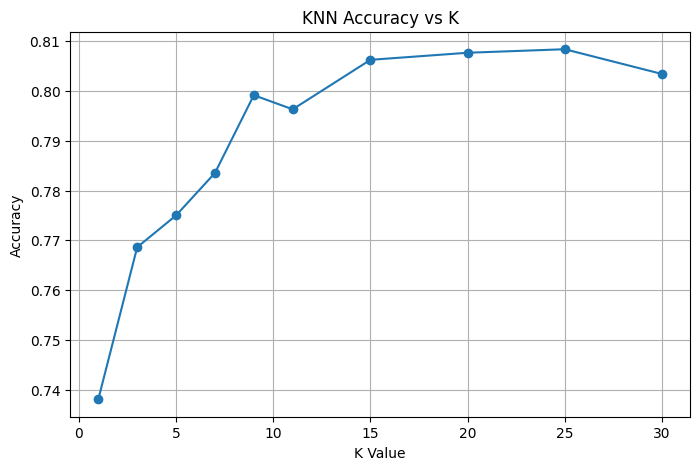

In [21]:
import matplotlib.pyplot as plt

# Filter one combination
graph_data = results_df[
    (results_df['Weights'] == 'uniform') &
    (results_df['Metric'] == 'euclidean')
]

# Sort by K
graph_data = graph_data.sort_values(by='K')

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    graph_data['K'],
    graph_data['Accuracy'],
    marker='o'
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.grid(True)

plt.show()
     